<a href="https://colab.research.google.com/github/zaluar05/Aprendizado-de-M-quina/blob/main/t1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!wget https://raw.githubusercontent.com/tltsilveira/ufsm00993/main/dataset_2.json

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Tratamento dos Dados

## 1 - Carregando os dados do dataset para uma estrutura de dados (dicionário)

In [ ]:
with open('dataset_2.json', 'r', encoding='utf-8') as arquivo:
    dicionario_data_set = json.load(arquivo)

print(dicionario_data_set)

{'X': [[0.068114, 0.835685], [-2.231097, 1.432963], [-2.877421, -1.274496], [-2.567255, -0.335642], [0.998976, 0.601887], [1.822129, -1.852982], [0.638047, -0.250792], [2.868331, 1.697094], [2.271341, 0.478024], [-0.407715, -0.238257], [-2.106115, -1.713298], [2.568513, 1.581452], [-1.451879, 0.159223], [2.915813, 1.413825], [0.214828, 1.077946], [0.261663, -0.974077], [1.306852, 1.734853], [0.094854, -0.025382], [1.715792, -1.164689], [0.418456, 1.277426], [0.228152, -0.317464], [-0.18052, 0.32019], [-2.757491, -1.58737], [0.674131, 1.827458], [-0.785833, 0.66931], [-0.905467, 0.192817], [1.224217, 0.17944], [0.366215, 1.839491], [1.924821, 0.925191], [2.267521, 0.933393], [-1.095125, -1.171001], [2.334442, 1.033296], [0.447379, 1.303283], [0.533899, 1.7742], [-2.699342, 1.105011], [-2.908372, 1.323824], [0.081087, 1.718406], [2.146035, -1.531443], [1.205891, -0.997701], [-0.255096, -1.565571], [-0.546672, -0.817069], [1.137919, -1.61698], [2.74769, -1.21048], [-2.882291, 0.307013], [

## 2 - Transformando 'X' e 'y' em tensores

In [ ]:
X = np.array(dicionario_data_set['X'])
y = np.array(dicionario_data_set['y'])


## 3 - Verificando a dimensão dos tensores:
### X - Uma matriz 600x2;
### y - Uma matriz 600x1;

In [ ]:
print(f"X tem {X.shape[0]} linhas e {X.shape[1]} colunas.")
print(f"y tem {y.shape[0]} linhas.")

print(X[:10])
print(y[:10])

X tem 600 linhas e 2 colunas.
y tem 600 linhas.
[[ 0.068114  0.835685]
 [-2.231097  1.432963]
 [-2.877421 -1.274496]
 [-2.567255 -0.335642]
 [ 0.998976  0.601887]
 [ 1.822129 -1.852982]
 [ 0.638047 -0.250792]
 [ 2.868331  1.697094]
 [ 2.271341  0.478024]
 [-0.407715 -0.238257]]
[0 1 0 1 0 0 0 1 1 1]


## 4 - Separação dos dados de treino e validação:
### Mesclar os dados para evitar viéses:

In [ ]:
np.random.seed(42)
indices = np.arange(X.shape[0]) # Cria um array de 0 a 599
np.random.shuffle(indices)
X_embaralhado = X[indices]

### Definindo o tamanho dos dados de treino e validação:


*   Treino - 80% dos dados (Até o oitavo decil)
*   Validação - Os 20% restantes



In [ ]:
tamanho_treino = int(0.8 * X.shape[0])

In [ ]:
X_treino = X_embaralhado[:tamanho_treino] # Pega do índice 0 ao 479
X_validacao = X_embaralhado[tamanho_treino:]   # Pega do índice 480 ao 599

## Z-Normalization

A **Z-Normalization** é uma técnica estatística e de pré-processamento de dados utilizada para redimensionar as características (features) de um conjunto de dados.

O objetivo principal é transformar os dados de forma que a sua distribuição tenha uma **média igual a zero** e um **desvio padrão igual a um**.

### Fórmula

A conversão de um valor original para o seu correspondente Z-score é feita utilizando a seguinte equação:

$$ z = \frac{x - \mu}{\sigma} $$

Onde:
*   $z$ é o valor padronizado (Z-score).
*   $x$ é o valor original do dado.
*   $\mu$ é a média populacional (ou amostral) daquela característica.
*   $\sigma$ é o desvio padrão populacional (ou amostral) da característica.

In [ ]:
mu = np.mean(X_treino, axis=0)
sigma = np.std(X_treino, axis=0) + 1e-8 # 1e-8 evita divisão por zero

In [ ]:
X_treino_normalizado = (X_treino - mu) / sigma
print(f"Média das colunas de X_treino_normalizado: {np.mean(X_treino_normalizado,axis=0)}")
print(f"Desvio padrão das colunas de X_treino_normalizado: {np.std(X_treino_normalizado, axis=0)}")

X_validacao_normalizado = (X_validacao - mu) / sigma
print(f"Média das colunas de X_validacao_normalizado: {np.mean(X_validacao_normalizado,axis=0)}")
print(f"Desvio padrão das colunas de X_validacao_normalizado: {np.std(X_validacao_normalizado, axis=0)}")


Média das colunas de X_treino_normalizado: [-4.14020670e-17 -3.00685403e-17]
Desvio padrão das colunas de X_treino_normalizado: [0.99999999 0.99999999]
Média das colunas de X_validacao_normalizado: [-0.10225446 -0.04899499]
Desvio padrão das colunas de X_validacao_normalizado: [1.05001422 0.96244563]


# Visualização dos Dados

## 1 - Dados de treino brutos, sem nenhuma alteração

Text(0.5, 1.0, 'Dados brutos')

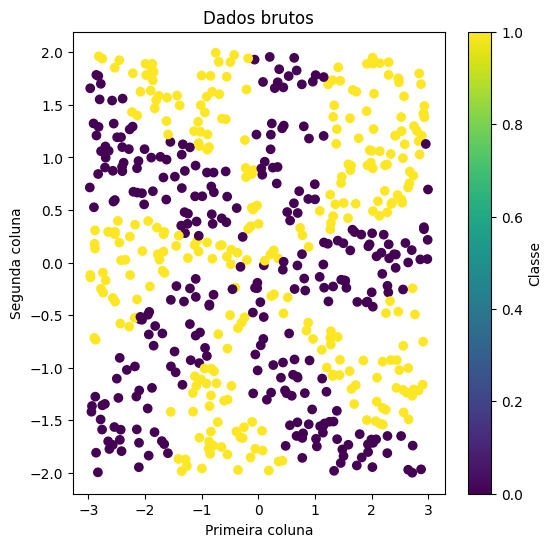

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Primeira coluna')
plt.ylabel('Segunda coluna')
plt.colorbar(label='Classe')
plt.title('Dados brutos')


## 2 - Dados de treino

Text(0.5, 1.0, 'Dados de Treino')

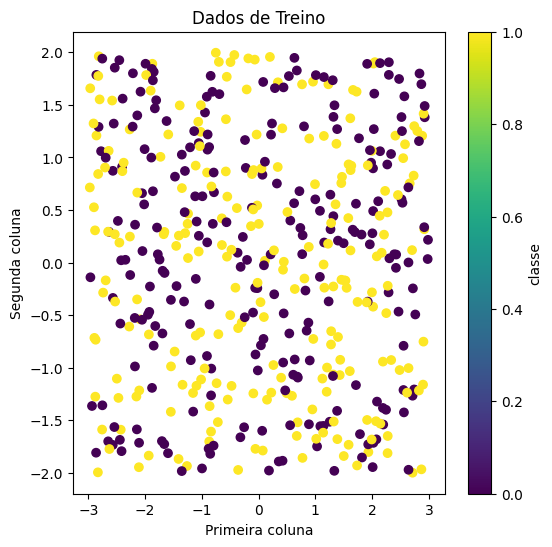

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(X_treino[:, 0], X_treino[:, 1],c=y[:tamanho_treino])
plt.xlabel('Primeira coluna')
plt.ylabel('Segunda coluna')
plt.colorbar(label='classe')
plt.title('Dados de Treino')

## 3 - Dados de treino **mesclados**

Text(0.5, 1.0, 'Dados Mesclados')

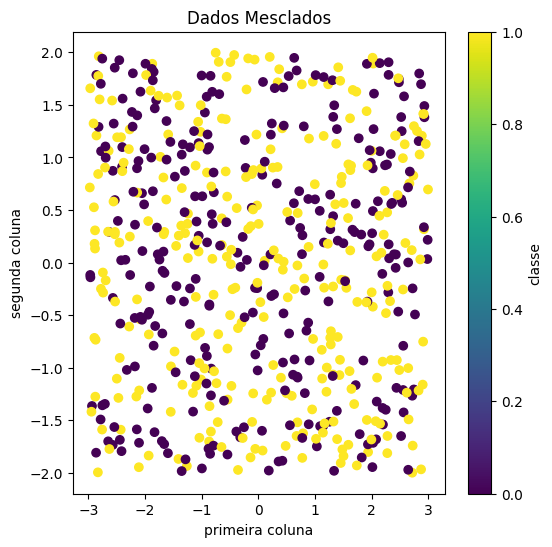

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(X_embaralhado[:, 0], X_embaralhado[:, 1], c=y)
plt.xlabel('Primeira coluna')
plt.ylabel('Segunda coluna')
plt.colorbar(label='classe')
plt.title('Dados Mesclados')

## 4 - Dados de treino normalizados

Text(0.5, 1.0, 'Dados de Treino Normalizados')

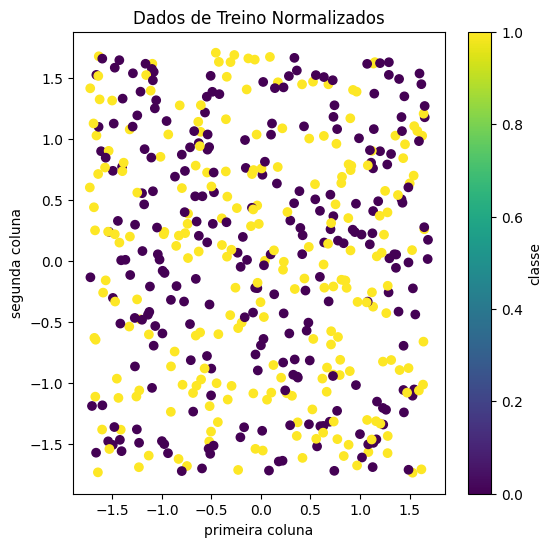

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(X_treino_normalizado[:, 0], X_treino_normalizado[:, 1], c=y[:tamanho_treino])
plt.xlabel('Primeira coluna')
plt.ylabel('Segunda coluna')
plt.colorbar(label='classe')
plt.title('Dados de Treino Normalizados')

# Funções de Ativação


## ReLu

**Rectified Linear Unit**

#### Fórmula

$$
f(x) = \max(0, x)
$$

Essa mesma função pode ser representada através da seguinte condição:

$$
f(x) = \begin{cases}
  x, & \text{se } x > 0 \\
  0, & \text{se } x \le 0
\end{cases}
$$

#### Derivada

A derivada da função ReLU utilizada no **backpropagation**

$$
f'(x) = \begin{cases}
  1, & \text{se } x > 0 \\
  0, & \text{se } x < 0
\end{cases}
$$

Tecnicamente a função não é diferenciável em 0, entretanto bibliotecas atribuem 0 a esse ponto.

In [ ]:
def relu(x):
  return np.maximum(0, x)

In [ ]:

def relu_derivada(x):
  return np.where(x > 0, 1, 0)

## Sigmoid

A principal característica da função é mapear qualquer valor real de entrada para um intervalo entre **$0$ e $1$**.

#### Fórmula


$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Se o valor de $x$ for um número positivo muito grande, $\sigma(x)$ se aproxima de $1$. Se $x$ for um número negativo muito grande, $\sigma(x)$ se aproxima de $0$. Quando $x = 0$, a saída é exatamente $0.5$.

#### Derivada

A derivada da função Sigmoide utilizada no **backpropagation**:
$$
\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))
$$

**O Comportamento da Derivada:**
Diferente da ReLU (cuja derivada para valores positivos é sempre $1$), o valor máximo da derivada da Sigmoide é **$0.25$** (que ocorre exatamente quando $x = 0$). À medida que os valores de $x$ vão ficando muito grandes (positivos) ou muito pequenos (negativos), a curva da função se achata, e **a derivada se aproxima rapidamente de $0$**.

A Sigmoide é ótima para problemas de classificação binária, onde queremos prever a probabilidade de um evento acontecer.

In [ ]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

In [ ]:
def sigmoid_derivada(x):
  return sigmoid(x) * (1 - sigmoid(x))

### Tangente Hiperbólica


In [ ]:
def tanh(z):
  return math.exp(z) - math.exp(-z) / math.exp(z) + math.exp(-z)

def tahn_derivada(z):
  return 1 - (tanh(z) ** 2)

## Softmax

É como uma generalização da Sigmoid para múltiplas camadas.Muito usada como função de ativação para a camada de saida de redes de classificação multiclasses.

Recebe um vetor de números reais e retorna um vetor de probabilidades.
#### Fórmula

Matematicamente, a função aplica a exponencial a cada elemento $z_i$ do vetor de entrada e normaliza o resultado dividindo-o pela soma das exponenciais de todos os $K$ elementos do vetor:

$$
\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

Onde:

* $z_i$ é o elemento atual do vetor (o valor "bruto" previsto para a classe $i$).
* $K$ é o número total de classes.
* $e$ é o número de Euler.

#### Por que utilizar?

1. **Distribuição de Probabilidades:** A grande mágica da Softmax é que **a soma de todas as suas saídas será sempre exatamente $1$** (ou $100\%$), e cada valor individual estará sempre entre $0$ e $1$. Isso permite interpretar a saída da rede como a probabilidade de o dado pertencer a cada classe.

2. **Destaque ao Vencedor (O Efeito "Max"):** O uso da base exponencial ($e^x$) faz com que valores maiores sejam muito ampliados, enquanto valores menores são "esmagados" em direção ao zero. Isso ajuda o modelo a tomar decisões mais confiantes sobre a classe vencedora.

3. **O Par Perfeito com a Cross-Entropy:** Na prática do Deep Learning, a Softmax é quase sempre combinada com a função de perda de **Entropia Cruzada Categórica** (*Categorical Cross-Entropy*). A combinação matemática da derivada dessas duas funções resulta em uma fórmula incrivelmente simples para o erro: $ \text{previsão} - \text{alvo} $ ($ \hat{y} - y $). Isso torna o processo de *backpropagation* extremamente eficiente e estável.

In [ ]:
def softmax(z):
  e = np.exp(z - np.max(z, axis=1, keepdims=True))
  return e / np.sum(e, axis=1, keepdims=True)

In [ ]:
def softmax_derivada(z):
  return softmax(z) * (1 - softmax(z))

# Funções de Perda

## Binary Cross Entropy

Função de perda muito utilizada em problemas de classificação binária.

#### Fórmula


$$
\text{BCE} = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]
$$

- $N$ é o número total de amostras.
- $y_i$ é a classe real do exemplo $i$ (que só pode ser $0$ ou $1$).
- $\hat{y}_i$ é a probabilidade prevista pelo modelo de que o exemplo pertença à classe $1$.
- $\log$ é o logaritmo natural.

Como $y_i$ só pode ser $0$ ou $1$, apenas uma das metades da equação dentro do somatório sobrevive de cada vez:
- Se a classe real for $1$ ($y_i = 1$), a segunda parte da equação é anulada e calculamos apenas: $- \log(\hat{y}_i)$
- Se a classe real for $0$ ($y_i = 0$), a primeira parte é anulada e calculamos apenas: $- \log(1 - \hat{y}_i)$

#### Derivada e a Regra da Cadeia

Para o **backpropagation**, precisamos calcular a derivada da perda em relação à probabilidade prevista $\hat{y}$:

$$
\frac{\partial \text{BCE}}{\partial \hat{y}_i} = \frac{\hat{y}_i - y_i}{\hat{y}_i (1 - \hat{y}_i)}
$$

##### Simplificação utilizando a Sigmoid

Sabemos que a previsão final $\hat{y}$ é gerada passando $z$ pela função Sigmoide ($\sigma$):

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

E sabemos que a derivada da função Sigmoide em relação a $z$ é:

$$
\frac{\partial \hat{y}}{\partial z} = \hat{y} \cdot (1 - \hat{y})
$$

Para encontrar a derivada da perda total em relação a $z$, aplicamos a **Regra da Cadeia**: multiplicamos a derivada da perda em relação a $\hat{y}$ pela derivada de $\hat{y}$ em relação a $z$:

$$
\frac{\partial \text{BCE}}{\partial z} = \frac{\partial \text{BCE}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z}
$$

Substituindo pelas fórmulas que vimos acima, temos o grande "truque" matemático:

$$
\frac{\partial \text{BCE}}{\partial z} = \left[ \frac{\hat{y} - y}{\hat{y} (1 - \hat{y})} \right] \cdot \left[ \hat{y} (1 - \hat{y}) \right]
$$

O termo $\hat{y} (1 - \hat{y})$ aparece tanto no denominador da primeira parte quanto multiplicando na segunda parte. **Eles se cancelam completamente**, restando apenas:

$$
\frac{\partial \text{BCE}}{\partial z} = \hat{y} - y
$$

In [ ]:
def binary_cross_entropy(y_pred,y_true):
  eps = 1e-15  # evita log(0)
  y_pred = np.clip(y_pred, eps, 1 - eps)
  return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [ ]:
def bce_sigmoid(y_pred,y_true):
  return y_pred - y_true

## Categorical Cross Entropy

Função de perda muito utilizada em problemas de classificação multiclasse, onde um exemplo só pode pertencer a uma única classe dentre três ou mais categorias possíveis.

#### Fórmula

$$
\text{CCE} = - \frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{K} y_{i,j} \log(\hat{y}_{i,j})
$$

* $N$ é o número total de amostras (exemplos).

* $K$ é o número total de classes.

* $y_{i,j}$ é o valor real da amostra $i$ para a classe $j$ (geralmente $1$ para a classe correta e $0$ para as demais).

* $\hat{y}_{i,j}$ é a probabilidade prevista pelo modelo de que a amostra $i$ pertença à classe $j$.

#### Derivada e simplificação utilizando a Softmax

Para atualizar os pesos da rede durante o *backpropagation*, precisamos saber como o erro (a perda $L$) muda em relação à saída bruta (*logit* $z_i$) da última camada, antes de aplicarmos a Softmax.

Para isso, usamos a **Regra da Cadeia**, multiplicando a derivada da perda pela derivada da ativação:

$$
\frac{\partial L}{\partial z_i} = \sum_{k=1}^{K} \frac{\partial L}{\partial \hat{y}_k} \cdot \frac{\partial \hat{y}_k}{\partial z_i}
$$

**Passo 1: A derivada da Perda (CCE)**
Se pegarmos apenas a parte da função de perda para uma única amostra, a derivada em relação à previsão $\hat{y}$ é bem direta:

$$
\frac{\partial L}{\partial \hat{y}_k} = -\frac{y_k}{\hat{y}_k}
$$

**Passo 2: A derivada da Softmax**
Como a Softmax divide a exponencial de uma classe pela soma de todas as classes, a derivada muda dependendo se estamos derivando em relação à própria classe ($k = i$) ou a outra classe ($k \neq i$):

* Quando $k = i$: $\frac{\partial \hat{y}_i}{\partial z_i} = \hat{y}_i(1 - \hat{y}_i)$
* Quando $k \neq i$: $\frac{\partial \hat{y}_k}{\partial z_i} = -\hat{y}_k \cdot \hat{y}_i$

**Passo 3: Juntando tudo**
Substituindo esses valores na regra da cadeia e separando o caso onde $k = i$ do somatório do resto das classes ($k \neq i$):

$$
\frac{\partial L}{\partial z_i} = \left( -\frac{y_i}{\hat{y}_i} \cdot \hat{y}_i(1 - \hat{y}_i) \right) + \sum_{k \neq i} \left( -\frac{y_k}{\hat{y}_k} \cdot (-\hat{y}_k \cdot \hat{y}_i) \right)
$$

Agora, simplificamos cortando os $\hat{y}$ que estão dividindo e multiplicando:

$$
\frac{\partial L}{\partial z_i} = -y_i(1 - \hat{y}_i) + \sum_{k \neq i} y_k \hat{y}_i
$$

Expandindo a equação:

$$
\frac{\partial L}{\partial z_i} = -y_i + y_i \hat{y}_i + \hat{y}_i \sum_{k \neq i} y_k
$$

Colocamos $\hat{y}_i$ em evidência:

$$
\frac{\partial L}{\partial z_i} = -y_i + \hat{y}_i \left( y_i + \sum_{k \neq i} y_k \right)
$$

Como $y$ é uma distribuição de probabilidade real (*One-Hot Encoding*), a soma de todos os $y$ para uma amostra é sempre $1$. Portanto, o termo dentro dos parênteses $\left( y_i + \sum y_k \right)$ é igual a $1$. Sobra apenas:

$$
\frac{\partial L}{\partial z_i} = \hat{y}_i - y_i
$$

Isso significa que o erro propagado é simplesmente: **(o que o modelo previu) - (o que deveria ter previsto)**. Essa simplificação elegante evita divisões complexas e torna o treinamento de redes multiclasse extremamente estável e rápido.

In [ ]:
def categorical_cross_entropy(y_pred,y_true):
  eps = 1e-15  # evita log(0)
  y_pred = np.clip(y_pred, eps, 1 - eps)
  return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

In [ ]:
def cce_softmax(y_pred,y_true):
  return y_pred - y_true

##

# Métricas de Classificação

Para compreender as fórmulas, utilizamos os seguintes blocos fundamentais:
* **TP (True Positive):** Ex: predizer 1 e o correto ser 1.
* **TN (True Negative):** Ex: predizer 0 e o correto ser 0.
* **FP (False Positive):** Ex: predizer 1 e o correto ser 0.
* **FN (False Negative):** Ex: predizer 0 e o correto ser 1.


## 1 - Acurácia

Mede a proporção geral de previsões corretas (tanto positivas quanto negativas) em relação ao total de previsões.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$


In [ ]:
def accuracy(y_true, y_pred):
  return np.mean(y_true == y_pred)

## 2 - Precisão

A Precisão responde à pergunta: **"De todos que eu predizi como classe 1, quantos realmente eram classe 1?"**

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

* **Uso:** Fundamental quando o custo de um **Falso Positivo** é alto. (Ex: Um filtro de spam, onde é muito ruim classificar um e-mail importante como spam).


In [ ]:
def precision(y_true, y_pred, label=1):
  true_positive = np.sum((y_true == label) & (y_pred == label))
  predicted_positive = np.sum(y_pred == label)
  if predicted_positive == 0:
    return 0
  return true_positive / predicted_positive

## 3 - Recall

A Revocação responde à pergunta: **"Quantas classes 1 reais eu consegui predizer do total?"**

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

* **Uso:** Fundamental quando o custo de um **Falso Negativo** é alto. (Ex: Detecção de câncer, onde é perigoso deixar passar um paciente doente dizendo que ele está saudável).


In [ ]:
def recall(y_true, y_pred, label=1):
  true_positives = np.sum((y_true == y_pred) & (y_pred == label))
  return true_positives / np.sum(y_true == label)


## 4 - F1-Score

O F1-Score é a **média harmônica** entre a Precisão e o Recall.

*(Nota: Na fórmula padrão estatística, multiplicamos por 2 para que o valor máximo seja 1).*

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

* **Uso:** Excelente para conjuntos de dados desbalanceados. Ele busca um equilíbrio: só será alto se tanto a Precisão quanto a Revocação forem altas.


In [ ]:
def f1_score(y_true, y_pred, label=1):
  p = precision(y_true, y_pred, label)
  r = recall(y_true, y_pred, label)
  return 1/((1/p) + (1/r))


## 5 - Matriz de Consfusão

Não é uma métrica única, mas sim uma **tabela** que sumariza o desempenho de um algoritmo de classificação. Ela cruza as **classes reais** (linhas) com as **classes preditas** (colunas), permitindo visualizar exatamente os acertos e os erros (TP, TN, FP, FN).

Para um problema binário, ela tem a seguinte estrutura:

$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

* **Uso:** É a base para calcular todas as métricas acima. O seu código constrói essa matriz iterando pelas classes únicas e contando as interseções entre `y_true` e `y_pred`.

In [ ]:
def confusion_matrix(y_true, y_pred):
  unique_labels = np.unique(y_true)
  n_labels = len(unique_labels)
  matrix = np.zeros((n_labels, n_labels), dtype=int)
  for i in range(n_labels):
    for j in range(n_labels):
      matrix[i, j] = np.sum((y_true == unique_labels[i]) & (y_pred == unique_labels[j]))
  return matrix

# Inicialização dos Pesos

## Inicialização He dos Pesos

A inicialização **He** é uma técnica utilizada para definir os pesos iniciais de uma rede neural, especialmente adequada para redes que utilizam funções de ativação **ReLU**. Os pesos são inicializados aleatoriamente a partir de uma distribuição com média zero e variância

$$
\mathrm{Var}(W) = \frac{2}{n_{in}}
$$

onde $n_{in}$ representa o número de neurônios de entrada da camada. Dessa forma, a inicialização He busca manter a variância das ativações aproximadamente estável ao longo das camadas, reduzindo problemas de **vanishing** ou **exploding gradients** durante o treinamento.

In [ ]:
def he(n_in, n_out):
  sigma = np.sqrt(2.0 / n_in)
  W = rng.normal(0.0, sigma, size=(n_in, n_out))
  b = np.zeros((1, n_out))
  return W, b

## Inicialização Aleatória

Na inicialização aleatória, os pesos da rede neural são inicializados com valores aleatórios próximos de zero. Neste caso, é utilizada uma distribuição normal com média zero e desvio padrão fixo de $0.01$:

$$
W \sim \mathcal{N}(0, 0.01^2)
$$

Essa inicialização fornece pequenas variações entre os neurônios, evitando que todos iniciem com os mesmos pesos. Entretanto, como o desvio padrão é fixo e não depende do número de entradas da camada, essa abordagem pode apresentar problemas de **vanishing** ou **exploding gradients** em redes mais profundas.

In [ ]:
def random(neuronios_entrada, neuronios_saida):
  std = 0.01
  W = rng.normal(0.0, std, size=(neuronios_entrada, neuronios_saida))
  b = np.zeros((1, neuronios_saida))
  return W, b

# Classe Multi-Layer-Perceptron

In [ ]:
# Cara, pensei em fazer assim. É so um esqueleto, mas podemos mudar a estrutura, da uma lida e ve oq
# tu acha.

In [ ]:
class Layer():
  def __init__(self, neurons, activation, initializer):
    # TODO: Inicialização dos pesos, foward e backward
    """
      Uso: model = MLP()
            model.add(layer(64, 'relu', 'he'))
            model.add(layer(32, 'tanh', 'random'))
            model.add(layer(1, 'sigmoid', 'he'))

    """
    rng =  np.random.default_rng()


    self.neurons = neurons
    self.activation = activation
    self.initializer = initializer
    self.weights = None
    self.bias = None

    def inicializar(self, n_in):
      n_out = self.neurons
      if self.initializer == 'he':
        sigma = np.sqrt(2.0 / n_in)

        self.weights = rng.normal(
            0.0,
            sigma,
            size=(n_in, n_out)
        )
      elif self.initializer == "random":
        self.weights = rng.normal(
            0.0,
            0.01,
            size=(n_in, n_out)
        )
      else:
            raise ValueError("Inicializador não adicionado")

      self.bias = np.zeros((1, n_out))

    def foward():


    def backward():
      pass



In [ ]:
ACTIVATION = {
    'relu' : (relu, relu_derivada),
    'tanh' : (tanh, tanh_derivada),
    'sigmoid' : (sigmoid, sigmoid_derivada),
    'softmax' : (softmax, softmax_derivada)
}

class MLP():
  def __init__(self, hidden_layers : list, loss : str, input_dim):
    """
    Inicialização da Classe MLP:
     -hidden_layers: ESPERA UMA lista de parametros neste formato:
     layers = [
      {"neurons": 64, "activation": "relu", "init": "he"},
      {"neurons": 32, "activation": "tanh", "init": "random"},
      {"neurons": 16, "activation": "relu", "init": "he"}]

      Em que temos chaves pro número de neurônios, função de ativação e inicialização
     -loss: Função de perda

     -----------------------------------------------------------------------------------

     Oque um objeto MLP deve guardar?
     - Pesos e Bias
     - Tamanho dos layers
     - Funções de ativação
     - Loss
     - Cache de resultados intermediários - Guardamos os resultados da ativação e soma ponderada
     a fim de calcular o gradiente de forma mais facil
     - Valores das loss do treino e validação

     -----------------------------------------------------------------------------------

     O MLP deverá ser treinado da seguinte forma:
      1 passo: Inicialização dos pesos da matriz - de forma aleatória ou He initializer
      2 passo: Com os pesos inicializados, receber o vetor entrada X e fazer o FOWARD
      3 passo: Depois do Foward, calcular a loss
      4 passo: Com o resultado da loss, realizar o backpropagation - gerando o vetor gradiente
      5 passo: Atualização dos pesos - somente agora, com base no vetor gradiente gerado da etapa 4,
      atualizar os pesos da matriz
      6 passo: Calcular os valores das métricas
    """

    self.hidden_layers = hidden_layers
    self.layers_size = [input_dim] + [layer["neurons"] for layer in hidden_layers]
    self.weights = []
    self.bias = []

    self.loss = loss
    self.loss_train = None
    self.loss_val = None

    self.cache = {}

    self.activations = []
    self.grad_activation = []
    self.initializers = []

    for layer in hidden_layers:
      self.activations.append(ACTIVATION[layer["activation"]][0])
      self.grad_activation.append(ACTIVATION[layer["activation"]][1])
      self.initializers.append(layer["init"])

    self._initialize_layers()

    def _initialize_layers(self):
      pass

    def foward(self, X):
      Z = []
      A = []
      i = 1

      while i < len(self.layers_size):
        Z.append(np.dot(X, self.weights[i-1]) + self.bias[i-1])
        if i == len(self.layers_size) - 1:
          A.append(self.output_activation(Z[i-1]))
        else:
          A.append(self.hidden_activation(Z[i-1]))

      return
    def backward()



# Callbacks

Podem ser chamadas durante o treinamento. O exemplo a ser implementada é o EarlyStopping, que monitora a loss da validação e interrompe o treinamento caso não melhorar em n repetições - paciência.

In [ ]:
class EarlyStopping():
    def __init__(self, patience : int, restore_best=True, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best = restore_best

        self.best_value = float("inf")
        self.wait = 0
        self.stop_training = False
        self.best_layers = None
        self.best_epoch = None

    def on_epoch_end(self, model, epoch, monitored_value):
        improved = monitored_value < self.best_value - self.min_delta

        if improved:
            self.best_value = monitored_value
            self.wait = 0
            self.best_epoch = epoch

            self.best_layers = copy.deepcopy(model.layers)

        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stop_training=True
                print(f"EarlyStopping: Interrompendo o treinamento na época {epoch}")


    def restore(self, model):
        if self.restore_best and self.best_layers is not None:
            print(f"EarlyStopping: Restaurando os melhores pesos do treinamento: época {self.best_epoch}")
            for model_layer, best_layer in zip(model.layers, self.best_layers):
                model_layer.W = best_layer.W.copy()
                model_layer.b = best_layer.b.copy()